In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [3]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\data-science-using-python\cleaned_student_depression_dataset.csv")
pd.set_option('display.max_columns',None)
df

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,1,3.0,1.0,0,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,0,3.0,2.0,1,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,0,9.0,1.0,1,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,1,4.0,5.0,1,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,1,1.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27873,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,1,7.0,1.0,1,0
27874,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,0,0.0,3.0,1,0
27875,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,0,12.0,2.0,0,0
27876,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,1,10.0,5.0,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27878 entries, 0 to 27877
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27878 non-null  int64  
 1   gender                                 27878 non-null  object 
 2   age                                    27878 non-null  float64
 3   city                                   27878 non-null  object 
 4   profession                             27878 non-null  object 
 5   academic_pressure                      27878 non-null  float64
 6   work_pressure                          27878 non-null  float64
 7   cgpa                                   27878 non-null  float64
 8   study_satisfaction                     27878 non-null  float64
 9   job_satisfaction                       27878 non-null  float64
 10  sleep_duration                         27878 non-null  object 
 11  di

In [5]:
#New dataframe 
new_df = df
#Checking for null values 
print(new_df.isnull().sum()) 
print("Missing values distribution: ")
print(new_df.isnull().mean())

id                                       0
gender                                   0
age                                      0
city                                     0
profession                               0
academic_pressure                        0
work_pressure                            0
cgpa                                     0
study_satisfaction                       0
job_satisfaction                         0
sleep_duration                           0
dietary_habits                           0
degree                                   0
have_you_ever_had_suicidal_thoughts_?    0
work/study_hours                         0
financial_stress                         0
family_history_of_mental_illness         0
depression                               0
dtype: int64
Missing values distribution: 
id                                       0.0
gender                                   0.0
age                                      0.0
city                                     0.0
pro

In [6]:
print(new_df.duplicated().any()) 

False


In [7]:
print(new_df.duplicated())
print(new_df.shape) 

0        False
1        False
2        False
3        False
4        False
         ...  
27873    False
27874    False
27875    False
27876    False
27877    False
Length: 27878, dtype: bool
(27878, 18)


In [8]:
df.drop("id", axis=1, inplace=True)


Class Distribution Before SMOTE:
depression
1    16329
0    11549
Name: count, dtype: int64


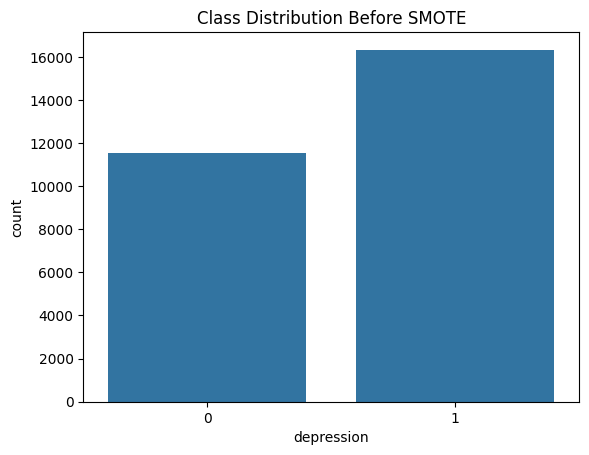

In [9]:
#Check Class Distribution (Before Balancing)
print("\nClass Distribution Before SMOTE:")
print(df['depression'].value_counts())

sns.countplot(x='depression', data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()


In [10]:
#Encode Categorical Variables
label_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.head())



After Encoding:
   gender   age  city  profession  academic_pressure  work_pressure  cgpa  \
0       1  33.0    51          11                5.0            0.0  8.97   
1       0  24.0     3          11                2.0            0.0  5.90   
2       1  31.0    44          11                3.0            0.0  7.03   
3       0  28.0    49          11                3.0            0.0  5.59   
4       0  25.0    16          11                4.0            0.0  8.13   

   study_satisfaction  job_satisfaction  sleep_duration  dietary_habits  \
0                 2.0               0.0               0               0   
1                 5.0               0.0               0               1   
2                 5.0               0.0               2               0   
3                 2.0               0.0               1               1   
4                 3.0               0.0               0               1   

   degree  have_you_ever_had_suicidal_thoughts_?  work/study_hours  \

In [11]:
#Split Features and Target
X = df.drop("depression", axis=1)
y = df["depression"]

In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Model Before SMOTE
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

print("Accuracy Before SMOTE:", accuracy_score(y_test, y_pred_before))
print(classification_report(y_test, y_pred_before))

Accuracy Before SMOTE: 0.8464849354375896
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      2316
           1       0.85      0.89      0.87      3260

    accuracy                           0.85      5576
   macro avg       0.84      0.84      0.84      5576
weighted avg       0.85      0.85      0.85      5576



C:\Users\USER\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Class Distribution After SMOTE:
depression
1    13069
0    13069
Name: count, dtype: int64


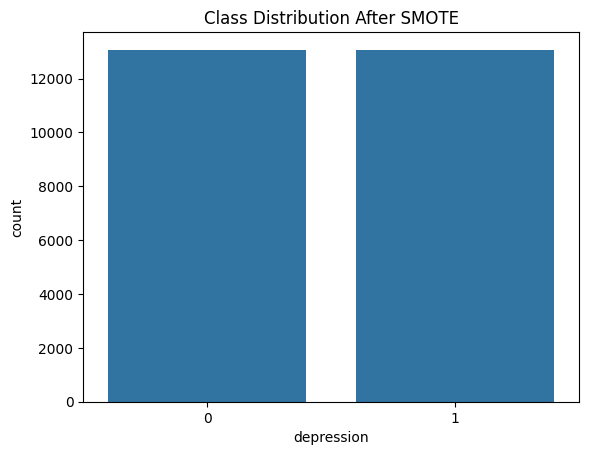

In [14]:
#Apply SMOTE to Handle Class Imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.show()

In [15]:
#Train Model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [16]:
# Predictions
y_pred = model.predict(X_test)


In [17]:
#Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8464849354375896

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      2316
           1       0.87      0.87      0.87      3260

    accuracy                           0.85      5576
   macro avg       0.84      0.84      0.84      5576
weighted avg       0.85      0.85      0.85      5576


Confusion Matrix:
[[1872  444]
 [ 412 2848]]
